In [1]:
import pandas as pd
import matplotlib.pyplot as plt




<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\au808919\AppData\Local\Temp\ipykernel_21428\3171868950.py:2: SyntaxWarning: invalid escape sequence '\p'
  file_path = "C:/mydoc\publications/fractional raster/final_esperiments/total_area_bias/total_area_bias_aarhus.csv"


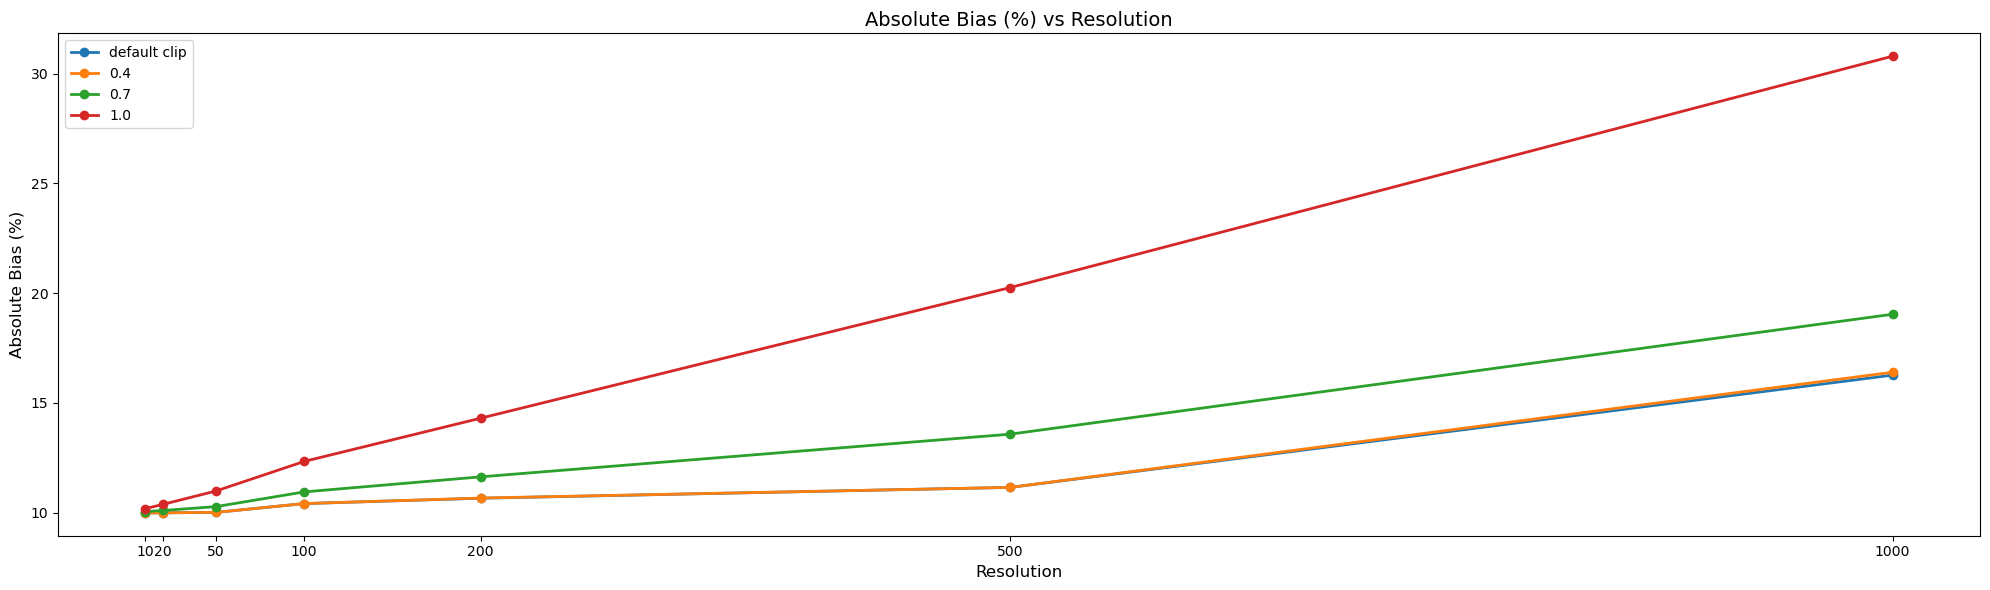

In [5]:
# Load CSV
file_path = "C:/mydoc\publications/fractional raster/final_esperiments/total_area_bias/total_area_bias_aarhus.csv"
df = pd.read_csv(file_path)

# Replace NaN threshold with readable label
df["threshold_label"] = df["threshold"].fillna("default clip")

# Use absolute value of bias
df["abs_bias_percent"] = df["bias_percent"].abs()

# Sort by resolution for consistent plotting
df = df.sort_values("resolution")

# Create larger figure (wider x-axis)
plt.figure(figsize=(20, 6))

for threshold in df["threshold_label"].unique():
    subset = df[df["threshold_label"] == threshold]
    plt.plot(
        subset["resolution"],
        subset["abs_bias_percent"],
        marker="o",
        linewidth=2,
        label=f"{threshold}"
    )

plt.xlabel("Resolution", fontsize=12)
plt.ylabel("Absolute Bias (%)", fontsize=12)
plt.title("Absolute Bias (%) vs Resolution", fontsize=14)

# Make sure all resolutions appear on x-axis
plt.xticks(df["resolution"].unique())

plt.legend()
plt.tight_layout()
plt.show()

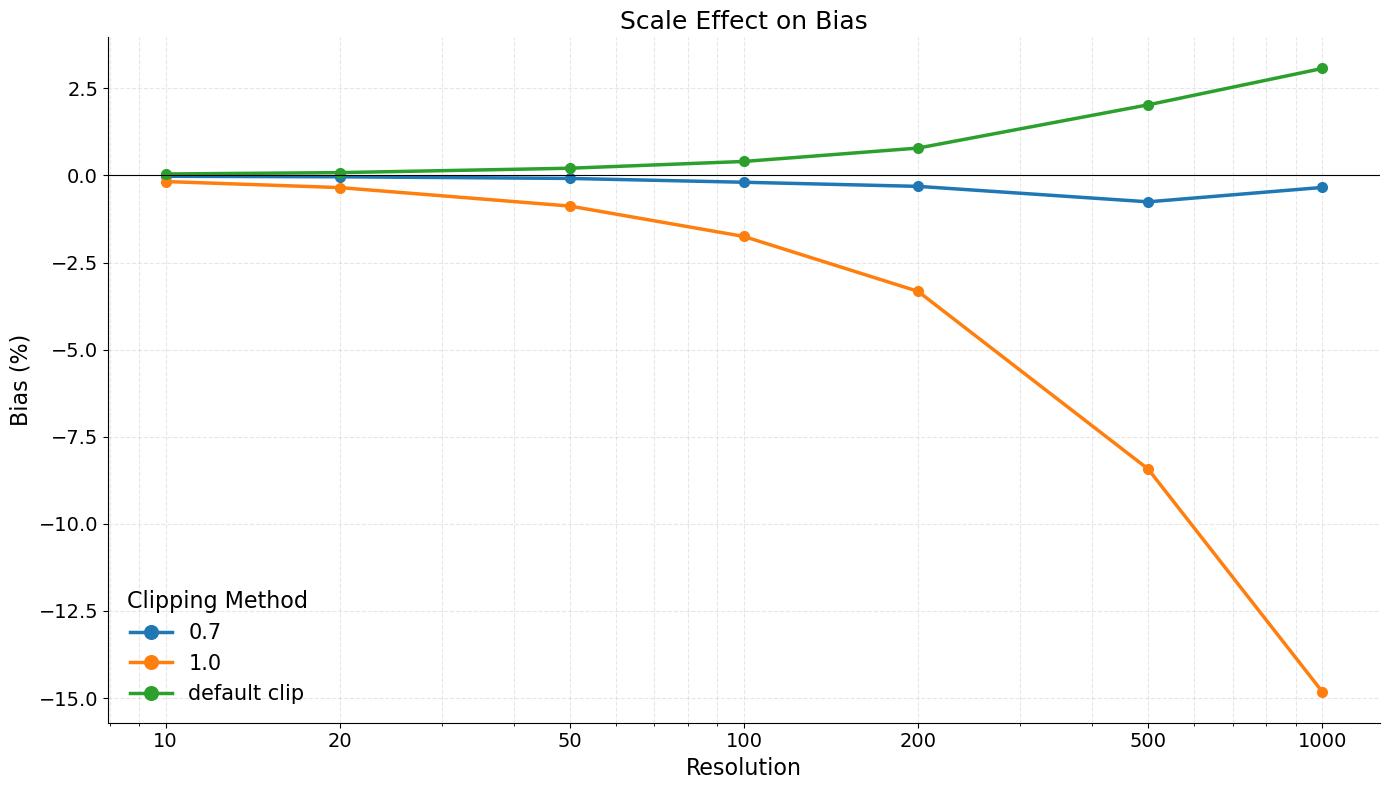

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# --------------------------------------------------
# Load Data
# --------------------------------------------------
file_path = "C:/mydoc/publications/fractional raster/final_esperiments/total_area_bias/total_area_bias_aarhus_correct.csv"
df = pd.read_csv(file_path)

# --------------------------------------------------
# Prepare Data
# --------------------------------------------------
df["threshold_label"] = df["threshold"].fillna("default clip")
df["abs_bias_percent"] = df["bias_percent"].abs()
df = df.sort_values("resolution")

# --------------------------------------------------
# Create Figure
# --------------------------------------------------
plt.figure(figsize=(14, 8))

for threshold in sorted(df["threshold_label"].unique(), key=str):
    subset = df[df["threshold_label"] == threshold]
    plt.plot(
        subset["resolution"],
        subset["bias_percent"],
        marker="o",
        markersize=7,
        linewidth=2.5,
        label=str(threshold)
    )

# --------------------------------------------------
# Log Scale + Proper Tick Control
# --------------------------------------------------
plt.xscale("log")

ax = plt.gca()

ax.set_xticks([10, 20, 50, 100, 200, 500, 1000])
ax.get_xaxis().set_major_formatter(ticker.ScalarFormatter())
ax.ticklabel_format(style='plain', axis='x')

# --------------------------------------------------
# Labels and Title
# --------------------------------------------------
plt.xlabel("Resolution", fontsize=16)
plt.ylabel("Bias (%)", fontsize=16)
plt.title("Scale Effect on Bias", fontsize=18)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# --------------------------------------------------
# Clean Axis Style
# --------------------------------------------------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(0.8)
ax.spines["left"].set_linewidth(0.8)

# Thin zero reference line
plt.axhline(0, color="black", linewidth=0.8)

# --------------------------------------------------
# Legend (Improved Size)
# --------------------------------------------------
plt.legend(
    title="Clipping Method",
    fontsize=15,
    title_fontsize=16,
    markerscale=1.4,
    frameon=False
)

# Light grid
plt.grid(True, which="both", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\au808919\AppData\Local\Temp\ipykernel_21428\2848229940.py:2: SyntaxWarning: invalid escape sequence '\p'
  file_path = "C:/mydoc\publications/fractional raster/final_esperiments/total_area_bias/total_area_bias_aarhus_correct.csv"


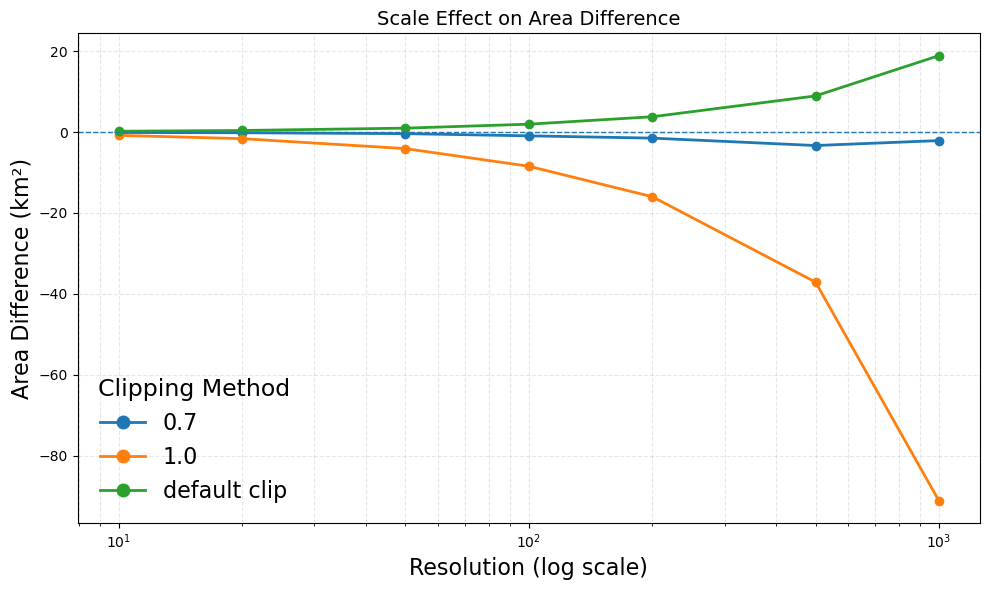

In [64]:

# Load data
file_path = "C:/mydoc\publications/fractional raster/final_esperiments/total_area_bias/total_area_bias_aarhus_correct.csv"
df = pd.read_csv(file_path)

# Replace NaN threshold with label
df["threshold_label"] = df["threshold"].fillna("default clip")

# Sort properly
df = df.sort_values(["threshold_label", "resolution"])

plt.figure(figsize=(10, 6))

for label in sorted(df["threshold_label"].unique(), key=str):
    subset = df[df["threshold_label"] == label]
    
    plt.plot(
        subset["resolution"],
        subset["area_difference_km2"],
        marker="o",
        linewidth=2,
        label=str(label)
    )

# Log-scale because resolution grows multiplicatively
plt.xscale("log")

# Reference zero line (important for interpretation)
plt.axhline(0, linestyle="--", linewidth=1)

plt.xlabel("Resolution (log scale)", fontsize=16)
plt.ylabel("Area Difference (km²)", fontsize=16)
plt.title("Scale Effect on Area Difference", fontsize=14)

#plt.legend(title="Clipping Method")
plt.grid(True, which="both", linestyle="--", alpha=0.3)

plt.legend(
    title="Clipping Method",
    fontsize=16,
    title_fontsize=17,
    markerscale=1.5,
    frameon=False
)


plt.tight_layout()
plt.show()


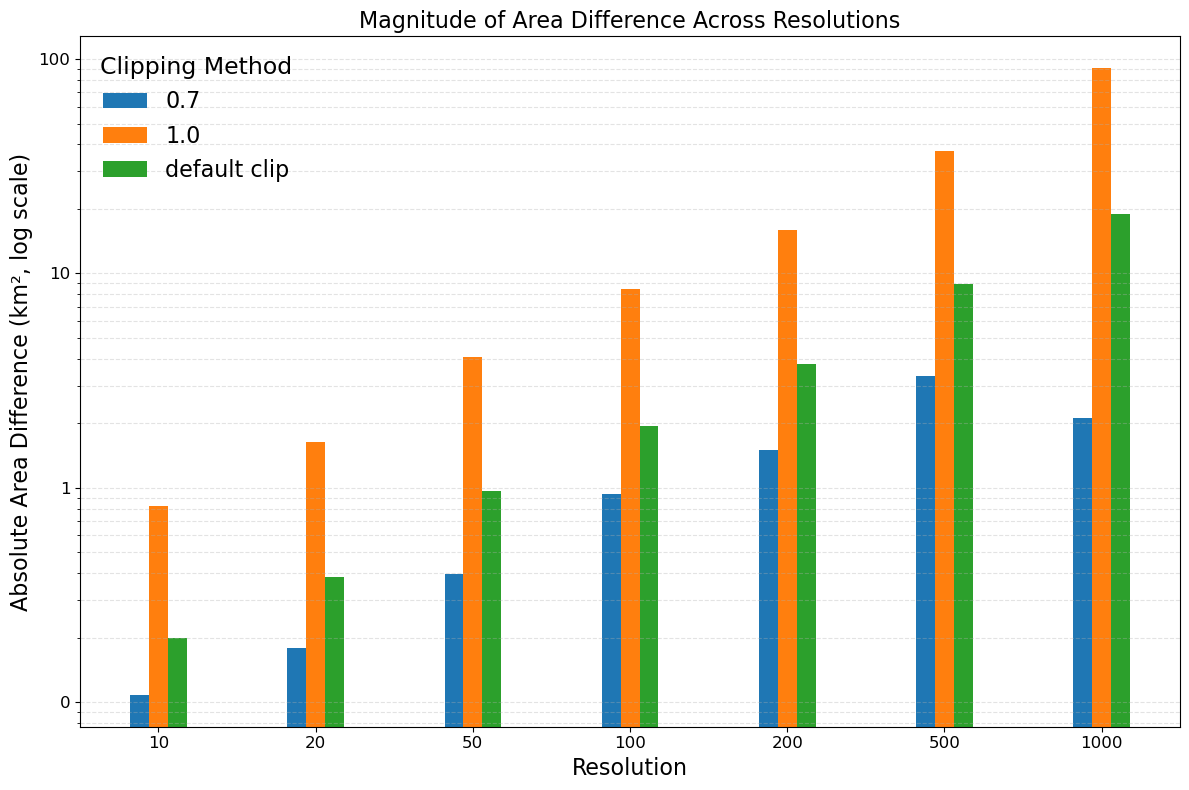

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Load data
file_path = "C:/mydoc/publications/fractional raster/final_esperiments/total_area_bias/total_area_bias_aarhus_correct.csv"
df = pd.read_csv(file_path)

# Prepare labels
df["threshold_label"] = df["threshold"].fillna("default clip")

# Use magnitude (absolute area difference)
df["abs_area_diff"] = df["area_difference_km2"].abs()

# Replace zeros (important for log scale)
df["abs_area_diff"] = df["abs_area_diff"].replace(0, 1e-6)

# Desired legend order
method_order = [0.7, 1.0, "default clip"]

# Resolution order
resolutions = sorted(df["resolution"].unique())
x = np.arange(len(resolutions))

bar_width = 0.12

plt.figure(figsize=(12, 8))

for i, method in enumerate(method_order):
    subset = df[df["threshold_label"] == method].set_index("resolution")
    subset = subset.reindex(resolutions)

    plt.bar(
        x + i * bar_width,
        subset["abs_area_diff"],
        width=bar_width,
        label=str(method)
    )

# Center tick labels
plt.xticks(
    x + bar_width * (len(method_order) - 1) / 2,
    resolutions,
    fontsize=12
)

# ---- Log Y-axis ----
plt.yscale("log")

plt.xlabel("Resolution", fontsize=16)
plt.ylabel("Absolute Area Difference (km², log scale)", fontsize=16)
plt.title("Magnitude of Area Difference Across Resolutions", fontsize=16)

# Cleaner log tick formatting
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.ticklabel_format(style='plain', axis='y')

plt.yticks(fontsize=12)

# Grid adapted for log scale
plt.grid(axis="y", which="both", linestyle="--", alpha=0.35)

plt.legend(
    title="Clipping Method",
    fontsize=16,
    title_fontsize=17,
    markerscale=1.5,
    frameon=False
)

plt.tight_layout()
plt.show()


### Land Cover Type boundary pixels biaises

In [19]:
# Load data
file_path = "C:/mydoc\publications/fractional raster/final_esperiments/total_area_bias/landcover_boundary_bias-experiment.csv"
df = pd.read_csv(file_path)

print(df.columns)
print(df.head())


Index(['commune', 'resolution', 'class_code', 'method', 'threshold',
       'reference_area_km2', 'area_km2', 'area_difference_km2', 'bias_percent',
       'class_name_en'],
      dtype='str')
  commune  resolution  class_code                method  threshold  \
0   Århus          10      211000               default        NaN   
1   Århus          10      211000  fractional_threshold        0.3   
2   Århus          10      211000  fractional_threshold        0.7   
3   Århus          10      211000  fractional_threshold        1.0   
4   Århus          10      121000               default        NaN   

   reference_area_km2  area_km2  area_difference_km2  bias_percent  \
0          198.504897  198.5591             0.054203      0.027306   
1          198.504897  198.5591             0.054203      0.027306   
2          198.504897  198.4763            -0.028597     -0.014406   
3          198.504897  198.2825            -0.222397     -0.112036   
4           51.671605   51.6767     

<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\au808919\AppData\Local\Temp\ipykernel_21428\4257495398.py:2: SyntaxWarning: invalid escape sequence '\p'
  file_path = "C:/mydoc\publications/fractional raster/final_esperiments/total_area_bias/landcover_boundary_bias-experiment.csv"


<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\au808919\AppData\Local\Temp\ipykernel_21428\1332376138.py:2: SyntaxWarning: invalid escape sequence '\p'
  file_path = "C:/mydoc\publications/fractional raster/final_esperiments/total_area_bias/landcover_boundary_bias-experiment.csv"


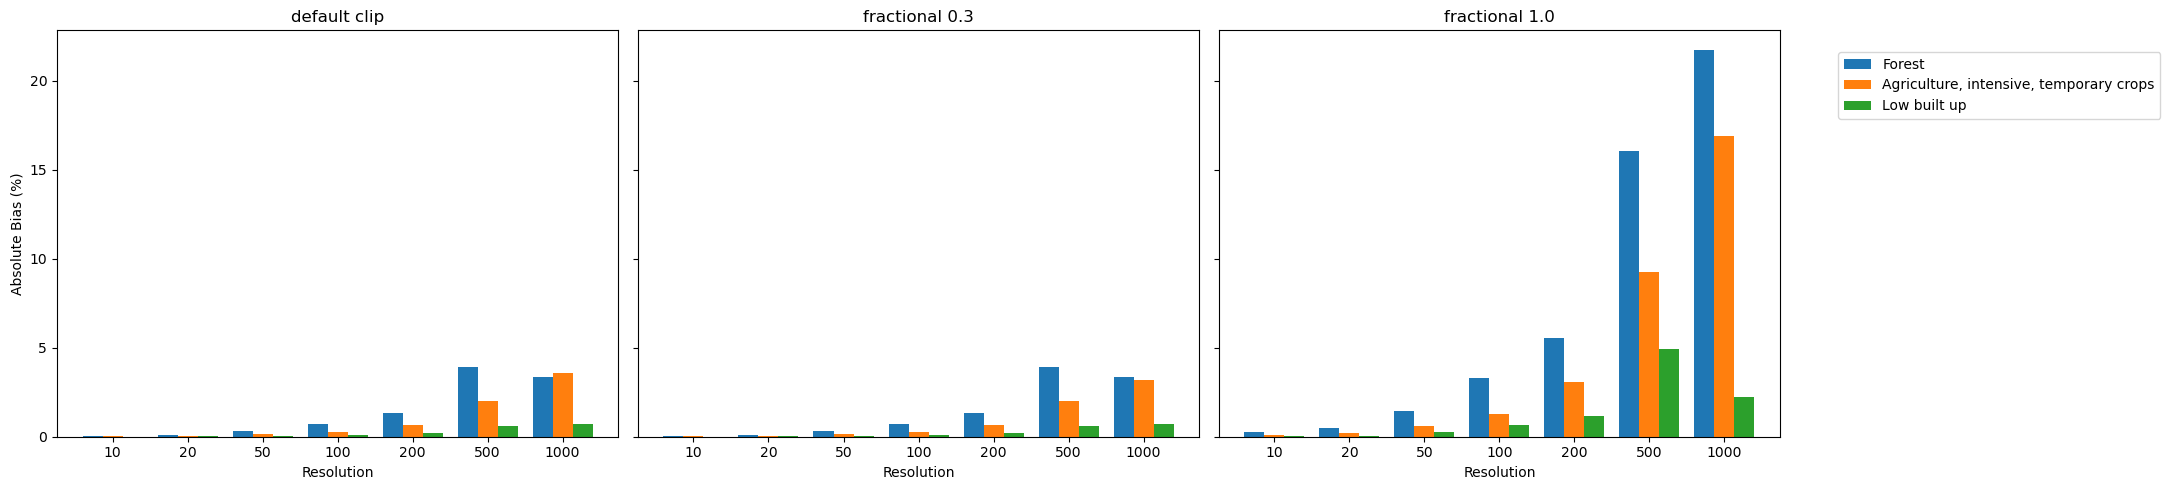

In [33]:


# Load data
file_path = "C:/mydoc\publications/fractional raster/final_esperiments/total_area_bias/landcover_boundary_bias-experiment.csv"
df = pd.read_csv(file_path)


# Create readable method label
df["method_label"] = df.apply(
    lambda row: "default clip"
    if row["method"] == "default"
    else f"fractional {row['threshold']}",
    axis=1
)

# Keep only desired methods
selected_methods = ["default clip", "fractional 0.3", "fractional 1.0"]
df = df[df["method_label"].isin(selected_methods)].copy()

# Absolute bias
df["abs_bias"] = df["bias_percent"].abs()

# Resolution order
resolutions = sorted(df["resolution"].unique())

# Class order (consistent across panels)
class_order = (
    df.groupby("class_name_en")["abs_bias"]
    .sum()
    .sort_values(ascending=False)
    .index
)

# ---- Plot ----
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, method in zip(axes, selected_methods):

    subset = df[df["method_label"] == method]

    x = np.arange(len(resolutions))
    bar_width = 0.8 / len(class_order)

    for i, cls in enumerate(class_order):
        class_data = (
            subset[subset["class_name_en"] == cls]
            .set_index("resolution")
            .reindex(resolutions)
        )

        values = class_data["abs_bias"].fillna(0).values

        ax.bar(
            x + i * bar_width,
            values,
            width=bar_width,
            label=cls
        )

    ax.set_xticks(x + bar_width * (len(class_order) - 1) / 2)
    ax.set_xticklabels(resolutions)
    ax.set_title(method)
    ax.set_xlabel("Resolution")

axes[0].set_ylabel("Absolute Bias (%)")

# One shared legend (cleaner)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.02, 0.9), loc="upper left")

plt.tight_layout()
plt.show()



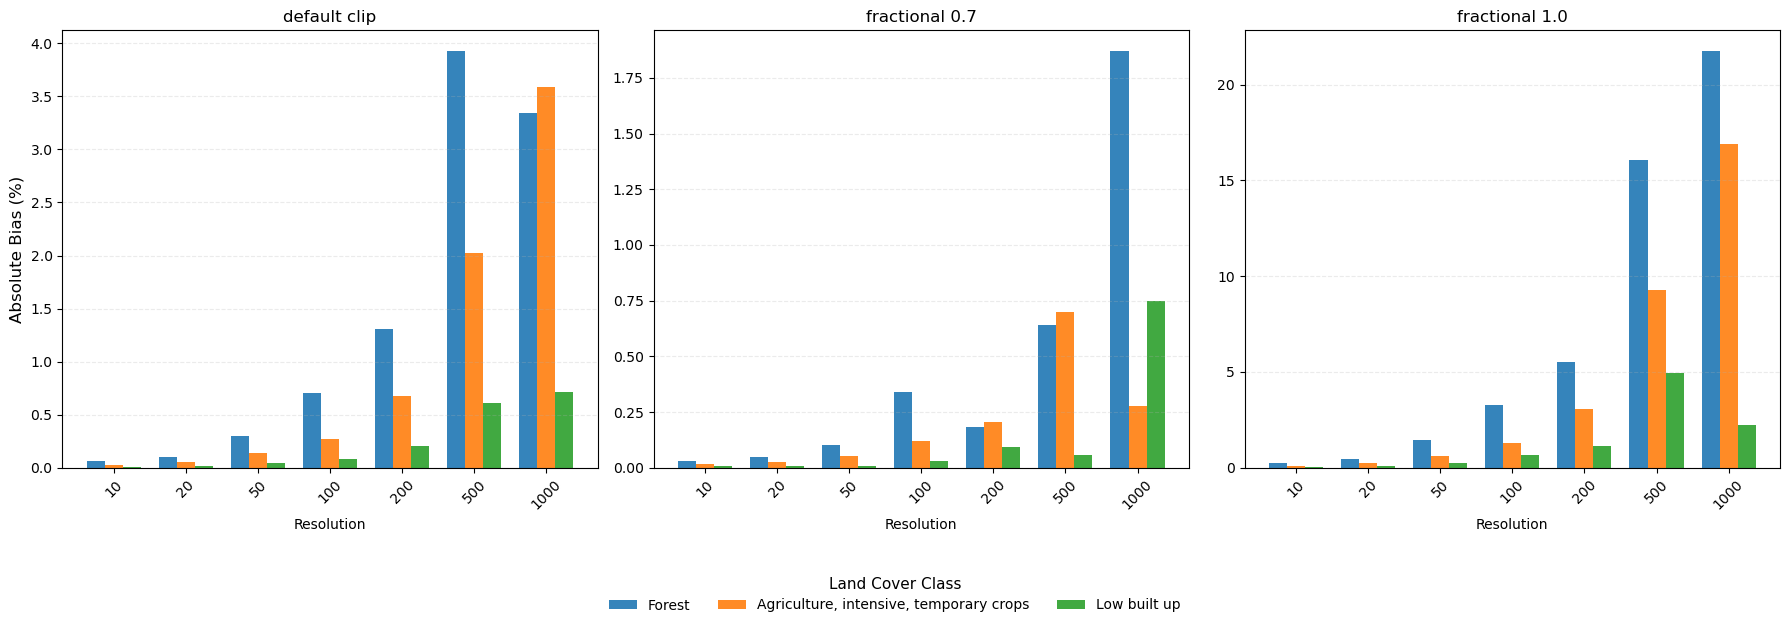

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

file_path = "C:/mydoc/publications/fractional raster/final_esperiments/total_area_bias/landcover_boundary_bias-experiment.csv"
df = pd.read_csv(file_path)

df["method_label"] = df.apply(
    lambda row: "default clip"
    if row["method"] == "default"
    else f"fractional {row['threshold']}",
    axis=1
)

selected_methods = ["default clip", "fractional 0.7", "fractional 1.0"]
df = df[df["method_label"].isin(selected_methods)].copy()

df["abs_bias"] = df["bias_percent"].abs()

resolutions = sorted(df["resolution"].unique())

class_order = (
    df.groupby("class_name_en")["abs_bias"]
    .sum()
    .sort_values(ascending=False)
    .index
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # slightly taller

for ax, method in zip(axes, selected_methods):

    subset = df[df["method_label"] == method]

    x = np.arange(len(resolutions))
    bar_width = 0.75 / len(class_order)

    for i, cls in enumerate(class_order):

        class_data = (
            subset[subset["class_name_en"] == cls]
            .set_index("resolution")
            .reindex(resolutions)
        )

        values = class_data["abs_bias"].fillna(0).values

        label = cls if ax == axes[0] else None

        ax.bar(
            x + i * bar_width,
            values,
            width=bar_width,
            alpha=0.9,
            label=label
        )

    ax.set_xticks(x + bar_width * (len(class_order) - 1) / 2)
    ax.set_xticklabels(resolutions, rotation=45)
    ax.set_title(method, fontsize=12)
    ax.set_xlabel("Resolution")
    ax.grid(axis="y", linestyle="--", alpha=0.25)

axes[0].set_ylabel("Absolute Bias (%)", fontsize=12)

# ---- Improved Legend ----
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=3,                  # split legend into columns
    fontsize=10,
    title="Land Cover Class",
    title_fontsize=11,
    frameon=False
)

plt.tight_layout(rect=[0, 0.08, 1, 1])  # reserve bottom space
plt.show()


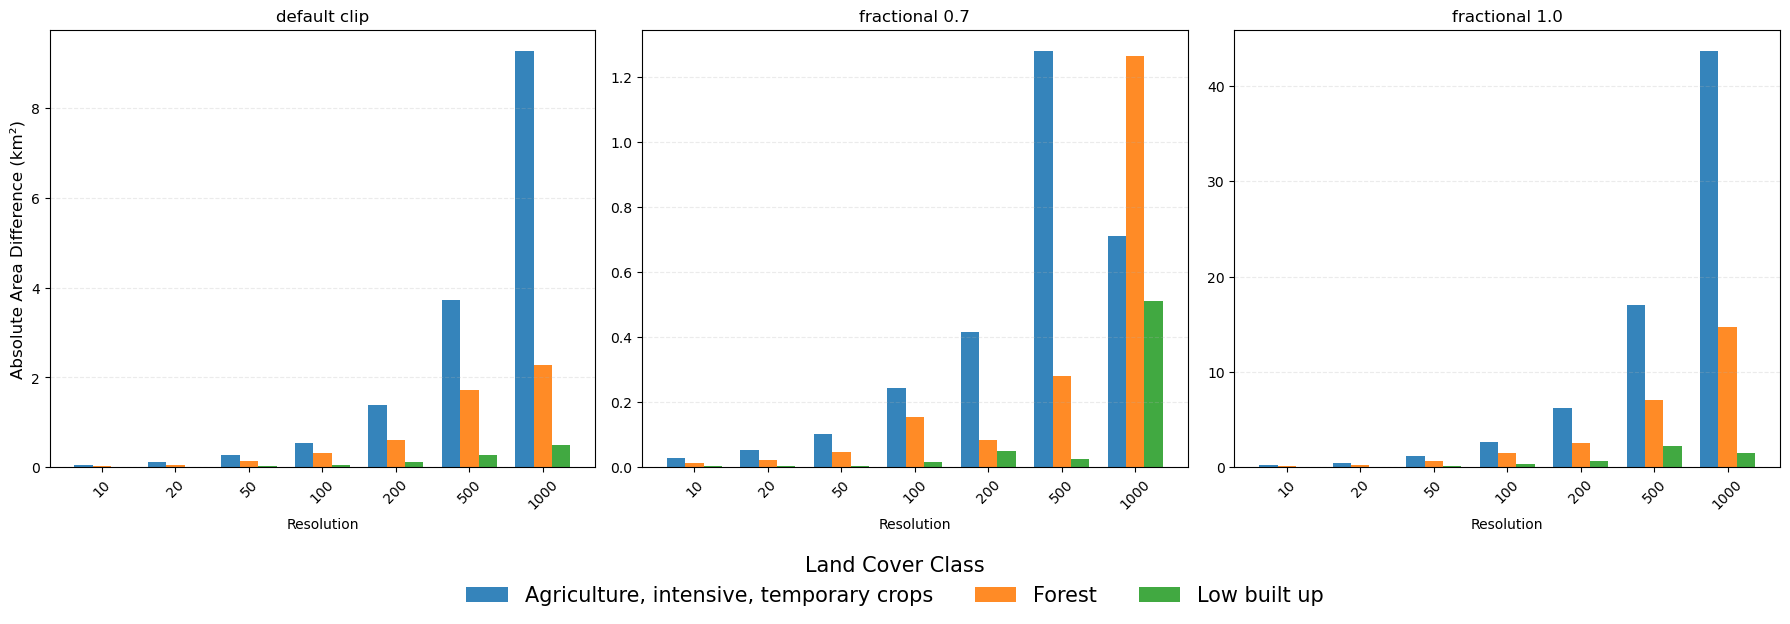

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
file_path = "C:/mydoc/publications/fractional raster/final_esperiments/total_area_bias/landcover_boundary_bias-experiment.csv"
df = pd.read_csv(file_path)

# Create readable method label
df["method_label"] = df.apply(
    lambda row: "default clip"
    if row["method"] == "default"
    else f"fractional {row['threshold']}",
    axis=1
)

# Select methods
selected_methods = ["default clip", "fractional 0.7", "fractional 1.0"]
df = df[df["method_label"].isin(selected_methods)].copy()

# Use absolute area difference
df["abs_area_diff"] = df["area_difference_km2"].abs()

# Resolution order
resolutions = sorted(df["resolution"].unique())

# Class order (dominant first, stable across panels)
class_order = (
    df.groupby("class_name_en")["abs_area_diff"]
    .sum()
    .sort_values(ascending=False)
    .index
)

# ---- Plot ----
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, method in zip(axes, selected_methods):

    subset = df[df["method_label"] == method]

    x = np.arange(len(resolutions))
    bar_width = 0.75 / len(class_order)

    for i, cls in enumerate(class_order):

        class_data = (
            subset[subset["class_name_en"] == cls]
            .set_index("resolution")
            .reindex(resolutions)
        )

        values = class_data["abs_area_diff"].fillna(0).values

        label = cls if ax == axes[0] else None

        ax.bar(
            x + i * bar_width,
            values,
            width=bar_width,
            alpha=0.9,
            label=label
        )

    ax.set_xticks(x + bar_width * (len(class_order) - 1) / 2)
    ax.set_xticklabels(resolutions, rotation=45)
    ax.set_title(method, fontsize=12)
    ax.set_xlabel("Resolution")
    ax.grid(axis="y", linestyle="--", alpha=0.25)

axes[0].set_ylabel("Absolute Area Difference (km²)", fontsize=12)

# ---- Shared legend (readable) ----
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=3,
    fontsize=15,
    title="Land Cover Class",
    title_fontsize=15,
    frameon=False
)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()


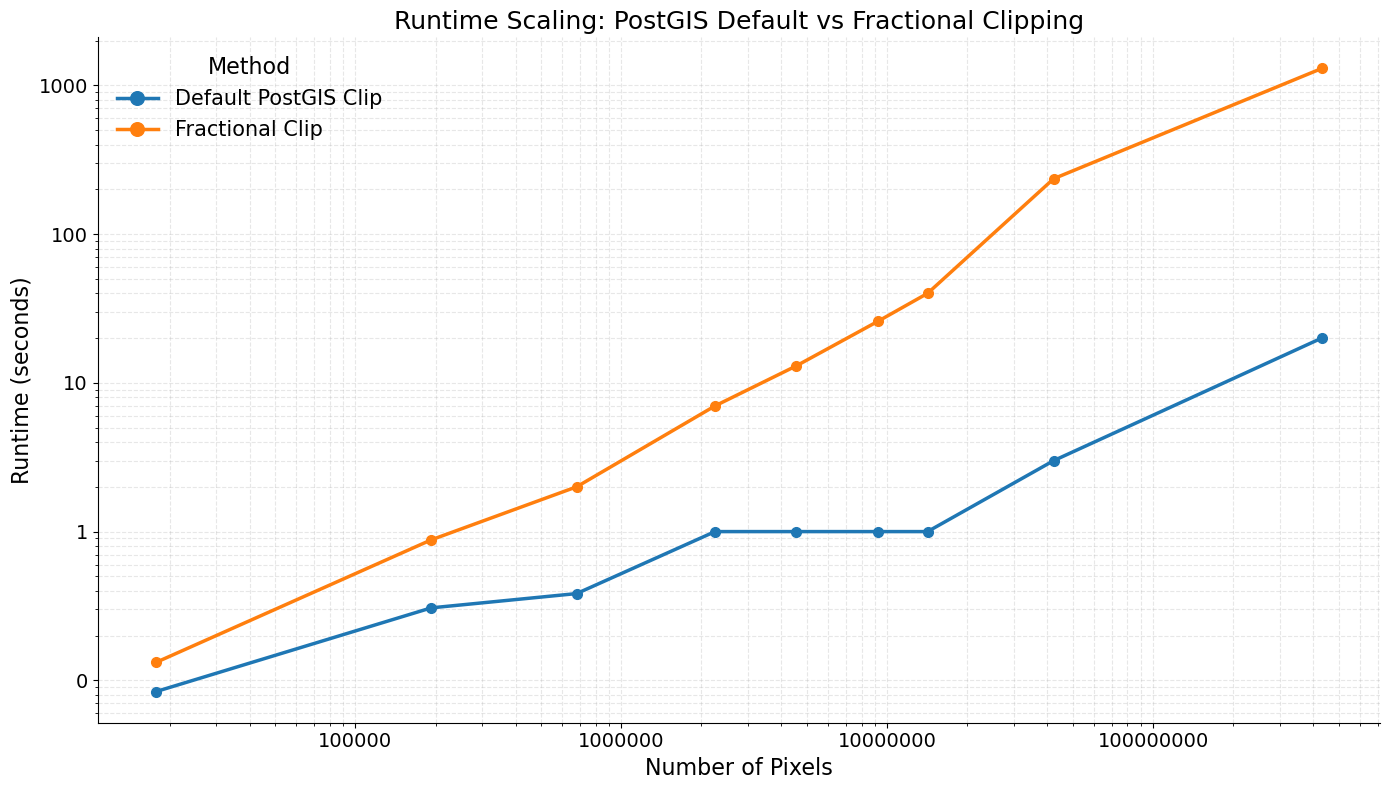

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Load data
file_path = "C:/mydoc/publications/fractional raster/final_esperiments/total_area_bias/default_vs_fractional_runtime.csv"
df = pd.read_csv(file_path)

# Sort by pixel number
df = df.sort_values("pixel_number")

plt.figure(figsize=(14, 8))

# Plot default
plt.plot(
    df["pixel_number"],
    df["default_clip_time"],
    marker="o",
    markersize=7,
    linewidth=2.5,
    label="Default PostGIS Clip"
)

# Plot fractional
plt.plot(
    df["pixel_number"],
    df["fractional_clip_time"],
    marker="o",
    markersize=7,
    linewidth=2.5,
    label="Fractional Clip"
)

# Log–log scaling (very important)
plt.xscale("log")
plt.yscale("log")

# Clean tick formatting
ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.ticklabel_format(style='plain', axis='both')

plt.xlabel("Number of Pixels", fontsize=16)
plt.ylabel("Runtime (seconds)", fontsize=16)
plt.title("Runtime Scaling: PostGIS Default vs Fractional Clipping", fontsize=18)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Clean axis style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(0.8)
ax.spines["left"].set_linewidth(0.8)

plt.legend(
    fontsize=15,
    title="Method",
    title_fontsize=16,
    markerscale=1.4,
    frameon=False
)

plt.grid(True, which="both", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


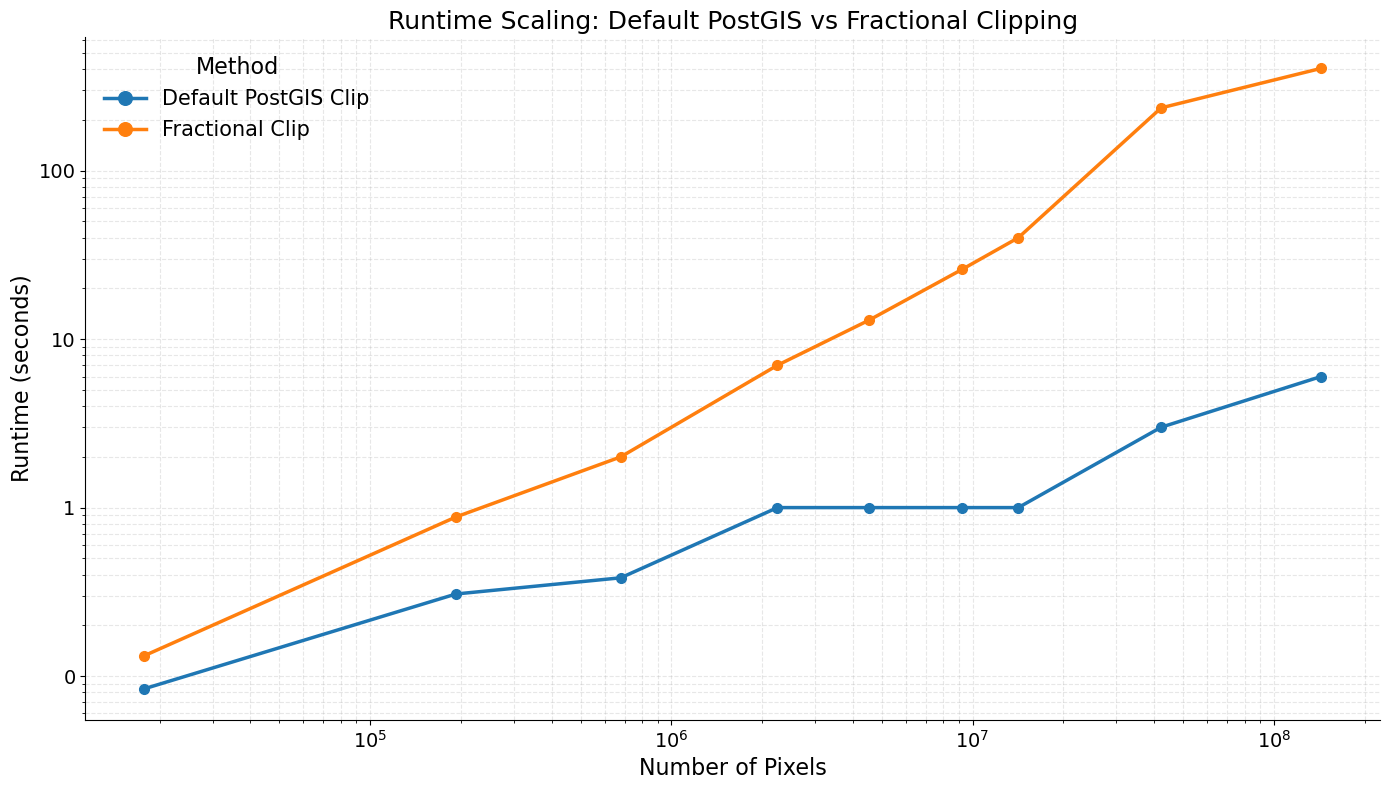

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Load data
file_path = "C:/mydoc/publications/fractional raster/final_esperiments/total_area_bias/default_vs_fractional_runtime.csv"
df = pd.read_csv(file_path)

# Sort
df = df.sort_values("pixel_number")

plt.figure(figsize=(14, 8))

# Plot Default PostGIS Clip
plt.plot(
    df["pixel_number"],
    df["default_clip_time"],
    marker="o",
    markersize=7,
    linewidth=2.5,
    label="Default PostGIS Clip"
)

# Plot Fractional Clip
plt.plot(
    df["pixel_number"],
    df["fractional_clip_time"],
    marker="o",
    markersize=7,
    linewidth=2.5,
    label="Fractional Clip"
)

# Log–log scaling
plt.xscale("log")
plt.yscale("log")

ax = plt.gca()

# ---- Format x-axis as 10^n ----
ax.xaxis.set_major_locator(ticker.LogLocator(base=10))
ax.xaxis.set_major_formatter(ticker.LogFormatterMathtext(base=10))

# Format y-axis normally (plain numbers)
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.ticklabel_format(style='plain', axis='y')

plt.xlabel("Number of Pixels", fontsize=16)
plt.ylabel("Runtime (seconds)", fontsize=16)
plt.title("Runtime Scaling: Default PostGIS vs Fractional Clipping", fontsize=18)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Clean axis style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(0.8)
ax.spines["left"].set_linewidth(0.8)

plt.legend(
    fontsize=15,
    title="Method",
    title_fontsize=16,
    markerscale=1.4,
    frameon=False
)

plt.grid(True, which="both", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


#### 430351221	20	1300??



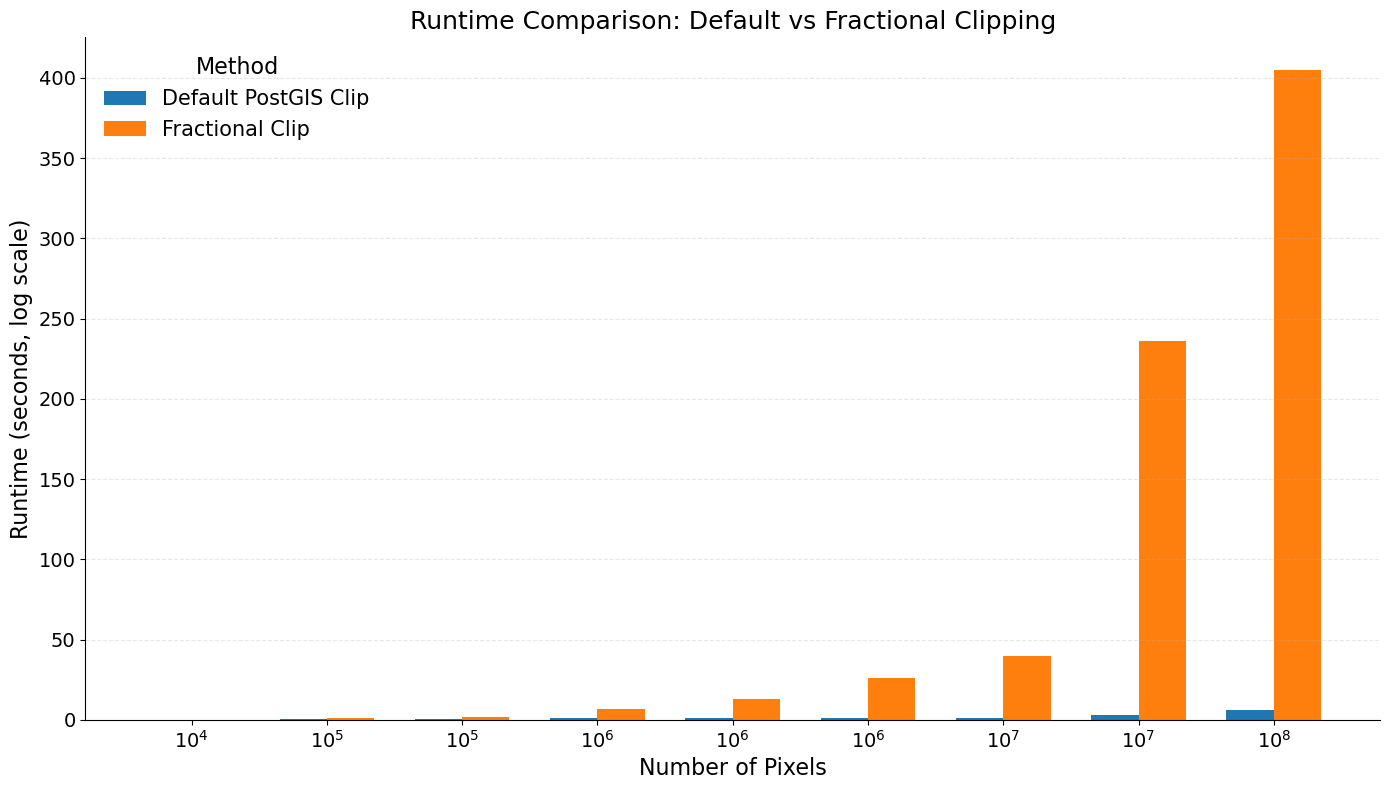

In [ ]:


# Load data
file_path = "C:/mydoc/publications/fractional raster/final_esperiments/total_area_bias/default_vs_fractional_runtime.csv"
df = pd.read_csv(file_path)

df = df.sort_values("pixel_number")

# Prepare X labels as 10^n
pixel_values = df["pixel_number"].values
x_labels = [r"$10^{%d}$" % int(np.log10(v)) for v in pixel_values]

x = np.arange(len(pixel_values))
bar_width = 0.35

plt.figure(figsize=(14, 8))

# Bars
plt.bar(
    x - bar_width/2,
    df["default_clip_time"],
    width=bar_width,
    label="Default PostGIS Clip"
)

plt.bar(
    x + bar_width/2,
    df["fractional_clip_time"],
    width=bar_width,
    label="Fractional Clip"
)

# Log Y-axis (important)
plt.yscale("log")

# Axis formatting
plt.xticks(x, x_labels, fontsize=14)
plt.yticks(fontsize=14)

# Format y-axis normally (plain numbers)
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.ticklabel_format(style='plain', axis='y')

plt.xlabel("Number of Pixels", fontsize=16)
plt.ylabel("Runtime (seconds, log scale)", fontsize=16)
plt.title("Runtime Comparison: Default vs Fractional Clipping", fontsize=18)

# Clean styling
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(0.8)
ax.spines["left"].set_linewidth(0.8)

plt.grid(axis="y", which="both", linestyle="--", alpha=0.3)

plt.legend(
    fontsize=15,
    title="Method",
    title_fontsize=16,
    frameon=False
)

plt.tight_layout()
plt.show()


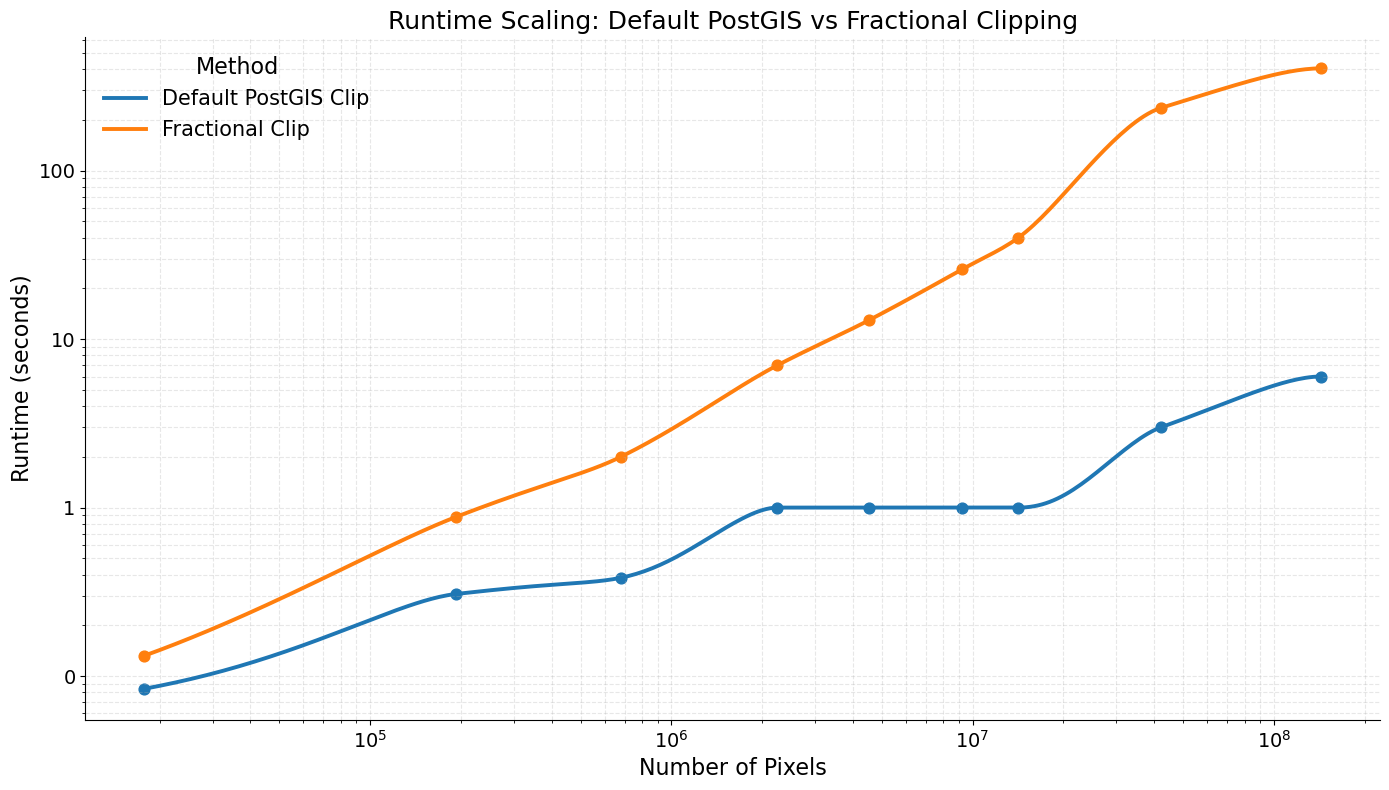

In [90]:
from scipy.interpolate import PchipInterpolator


# Load data
file_path = "C:/mydoc/publications/fractional raster/final_esperiments/total_area_bias/default_vs_fractional_runtime.csv"
df = pd.read_csv(file_path)
df = df.sort_values("pixel_number")

x = df["pixel_number"].values
y_default = df["default_clip_time"].values
y_fractional = df["fractional_clip_time"].values

# Create smooth x-range (log-spaced for correctness)
x_smooth = np.logspace(np.log10(x.min()), np.log10(x.max()), 300)

# Shape-preserving interpolation
interp_default = PchipInterpolator(x, y_default)
interp_fractional = PchipInterpolator(x, y_fractional)

y_default_smooth = interp_default(x_smooth)
y_fractional_smooth = interp_fractional(x_smooth)

plt.figure(figsize=(14, 8))

# Smooth curves
plt.plot(x_smooth, y_default_smooth, linewidth=2.8, label="Default PostGIS Clip")
plt.plot(x_smooth, y_fractional_smooth, linewidth=2.8, label="Fractional Clip")

# Original points (important for scientific transparency)
plt.scatter(x, y_default, s=60)
plt.scatter(x, y_fractional, s=60)

# Log–log scaling
plt.xscale("log")
plt.yscale("log")

ax = plt.gca()

# Format x-axis as 10^n
ax.xaxis.set_major_locator(ticker.LogLocator(base=10))
ax.xaxis.set_major_formatter(ticker.LogFormatterMathtext(base=10))

# Format y-axis normally (plain numbers)
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.ticklabel_format(style='plain', axis='y')

# Clean styling
plt.xlabel("Number of Pixels", fontsize=16)
plt.ylabel("Runtime (seconds)", fontsize=16)
plt.title("Runtime Scaling: Default PostGIS vs Fractional Clipping", fontsize=18)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(0.8)
ax.spines["left"].set_linewidth(0.8)

plt.legend(
    fontsize=15,
    title="Method",
    title_fontsize=16,
    frameon=False
)

plt.grid(True, which="both", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()
